In [162]:
import matplotlib.pyplot as plt
import matplotlib.colors as color
from matplotlib.lines import Line2D
import numpy as np

In [163]:
sizeMap = [None for __ in range(1, 7)]
fields = [None for __ in range(1, 7)]
for s in range(1, 7):
    with open(f"fields{str(s)}.txt", 'r') as fieldsF:
        nx, ny = map(int, fieldsF.readline().strip()[len("nx, ny = ") : ].split(" "))
        fields[s - 1] = [[0] * (ny + 1) for _ in range(nx + 1)]
        for line in fieldsF.readlines():
            line = line.strip().split('\t')
            i, j, v = int(line[0]), int(line[1]), float(line[2])
            fields[s - 1][i][j] = v
        sizeMap[s - 1] = (nx, ny)

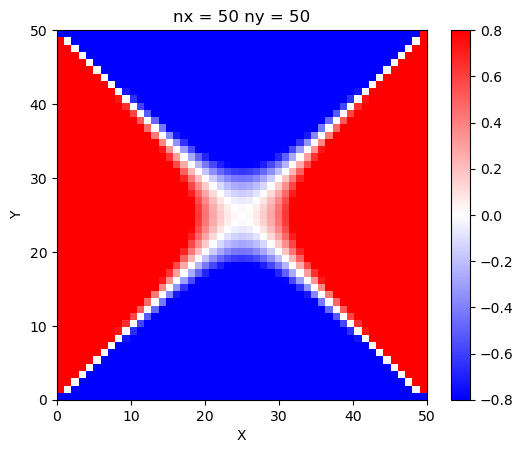

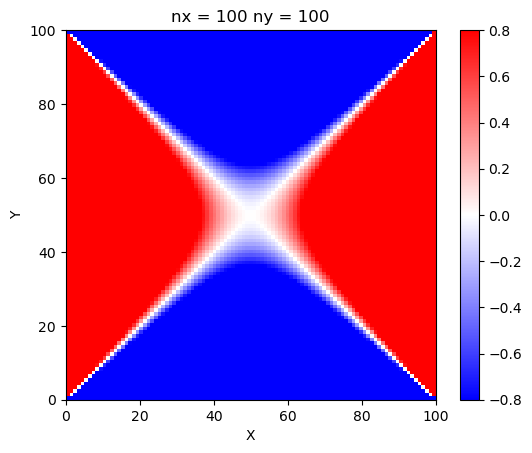

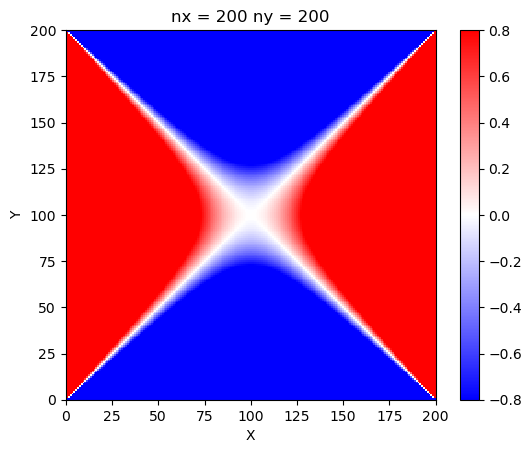

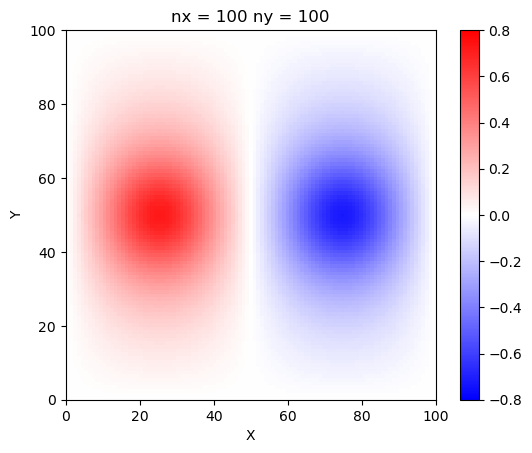

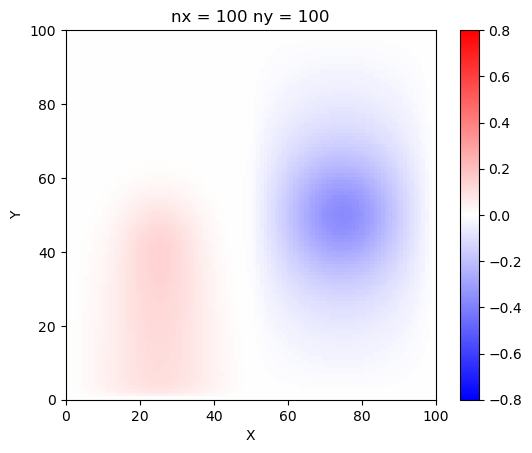

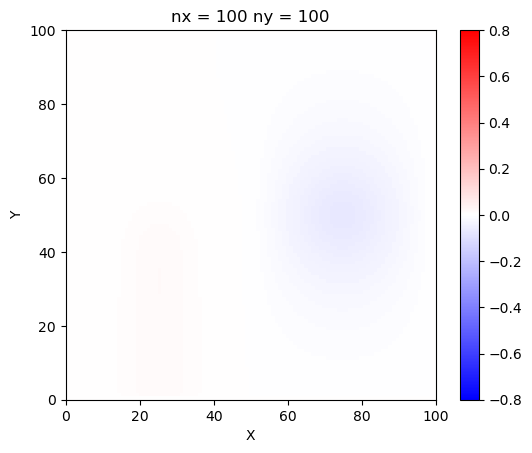

In [164]:
for i, (size, field) in enumerate(zip(sizeMap, fields), 1):
    contour = np.array(field).transpose()
    if i > 3:
        norm1 = color.TwoSlopeNorm(vmin=-0.8, vmax=0.8, vcenter=0)
        plt.imshow(contour, interpolation='none', origin='lower', cmap="bwr", extent=[0, size[0], 0, size[1]], norm=norm1)
    else:
        plt.imshow(contour, interpolation='none', origin='lower', cmap="bwr", extent=[0, size[0], 0, size[1]])
    plt.title(f"nx = {size[0]} ny = {size[1]}")
    plt.colorbar()
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.savefig(f"fig{i}.png")
    plt.show()
    # break